# Iris Classification

Load the iris dataset, train several classifiers, evaluate them with k-fold cross-validation and holdout test accuracy, and select the best model.

## Setup

Create and activate the conda environment, then launch Jupyter:

```bash
cd assignment5/ai
conda env create -f environment.yml
conda activate assignment5-ai
jupyter notebook iris_classification.ipynb
```

## Imports

In [8]:
# Data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt

# Model selection, splitting, and evaluation utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

# Classifiers to compare
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## Load Data

In [2]:
# The CSV has no header row, so we assign column names manually
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
df = pd.read_csv("../data/iris.csv", header=None, names=columns)

# Features (X): the four numeric measurements
X = df.iloc[:, :4]
# Target (y): the iris species label
y = df["species"]

# Quick checks to confirm dataset size and balanced classes
print(f"Shape: {df.shape}")
print("\nClass distribution:")
print(y.value_counts())

Shape: (150, 5)

Class distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## Train/Test Split

In [3]:
# Hold out 20% of the data for final evaluation
# stratify=y keeps the same class proportions in train and test sets
# random_state=42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 120 samples
Test set: 30 samples


## Train Classifiers

In [4]:
# Define several classifiers with reasonable default settings
# We will compare them on the same train/test split
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),  # linear decision boundary
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),        # vote among 5 nearest points
    "DecisionTree": DecisionTreeClassifier(random_state=42),  # single tree
    "RandomForest": RandomForestClassifier(random_state=42),  # ensemble of trees
    "SVC": SVC(random_state=42),                              # support vector classifier
}

## K-Fold Cross-Validation

In [5]:
# 5-fold stratified CV on training data only (test set stays untouched)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    # Estimate generalization on training folds
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

    # Fit on full training set, then evaluate once on held-out test set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "model": name,
        "cv_mean": cv_scores.mean(),   # average accuracy across CV folds
        "cv_std": cv_scores.std(),     # variability across folds
        "test_accuracy": test_accuracy,
    })

# Rank models by CV performance; break ties with test accuracy, then name
results_df = (
    pd.DataFrame(results)
    .sort_values(["cv_mean", "test_accuracy", "model"], ascending=[False, False, True])
    .reset_index(drop=True)
)
results_df

,model,cv_mean,cv_std,test_accuracy
0,KNeighbors,0.966667,0.016667,1.000000
1,SVC,0.966667,0.031180,0.966667
2,LogisticRegression,0.958333,0.026352,0.966667
3,DecisionTree,0.950000,0.016667,0.933333
4,RandomForest,0.950000,0.031180,0.900000


## Model Accuracy Comparison

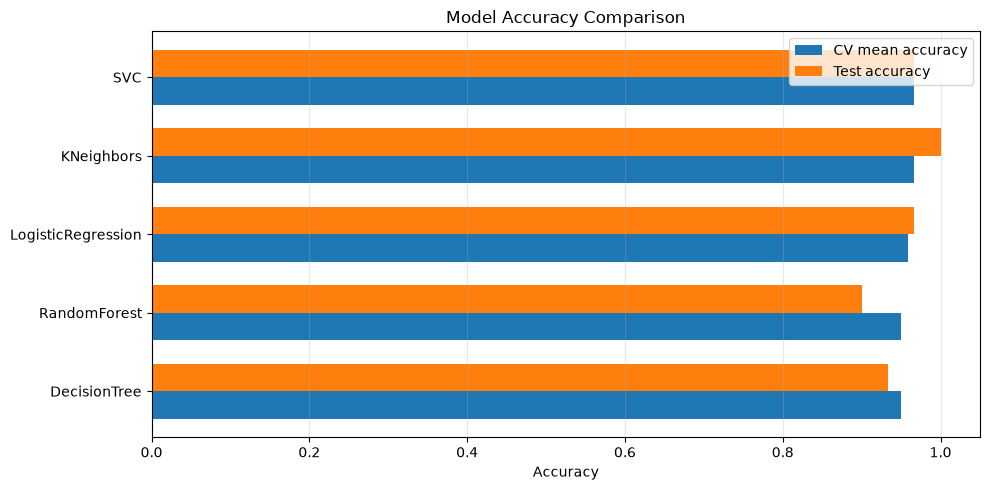

In [9]:
# Sort ascending so the highest-accuracy model appears at the top of the chart
plot_df = results_df.sort_values("cv_mean", ascending=True)

x = range(len(plot_df))
width = 0.35  # offset for side-by-side bars

fig, ax = plt.subplots(figsize=(10, 5))
# Pair of bars per model: CV estimate vs final test-set score
ax.barh([i - width / 2 for i in x], plot_df["cv_mean"], height=width, label="CV mean accuracy")
ax.barh([i + width / 2 for i in x], plot_df["test_accuracy"], height=width, label="Test accuracy")

ax.set_yticks(list(x))
ax.set_yticklabels(plot_df["model"])
ax.set_xlabel("Accuracy")
ax.set_xlim(0, 1.05)
ax.set_title("Model Accuracy Comparison")
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Select Best Model

In [6]:
# Top row in results_df is the best model after sorting
best = results_df.iloc[0]

print(f"Best model: {best['model']}")
print(f"  CV accuracy: {best['cv_mean']:.3f} (+/- {best['cv_std']:.3f})")
print(f"  Test accuracy: {best['test_accuracy']:.3f}")

Best model: KNeighbors
  CV accuracy: 0.967 (+/- 0.017)
  Test accuracy: 1.000
